### import  and  load  the cleaned  data sets    

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/cleaned_data.csv")
print("Shape:", df.shape)
df.head()   

Shape: (999769, 10)


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


###  yeild  distributions    

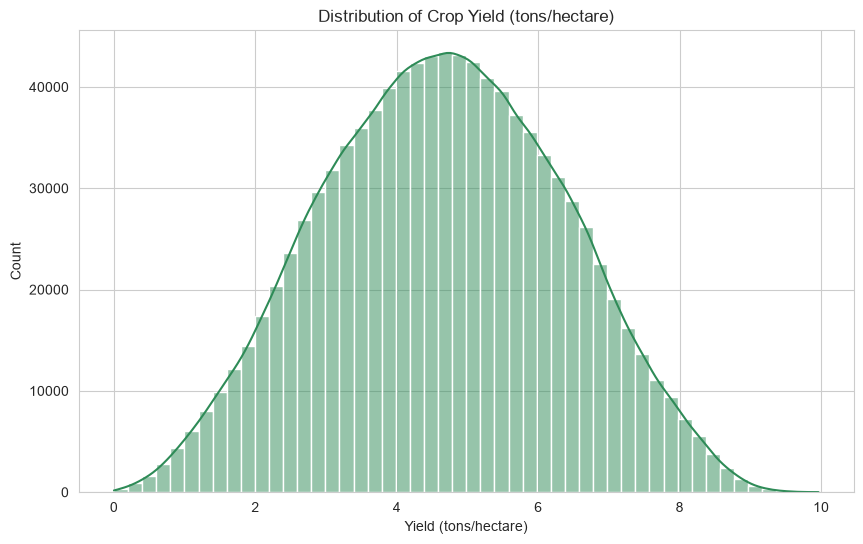

Skewness: 0.002575372921218981


In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Yield_tons_per_hectare"], kde=True, bins=50, color="seagreen")
plt.title("Distribution of Crop Yield (tons/hectare)")
plt.xlabel("Yield (tons/hectare)")
plt.savefig("../reports/figures/01_yield_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Skewness:", df["Yield_tons_per_hectare"].skew())   

###    Rainfall and Temperature distributions

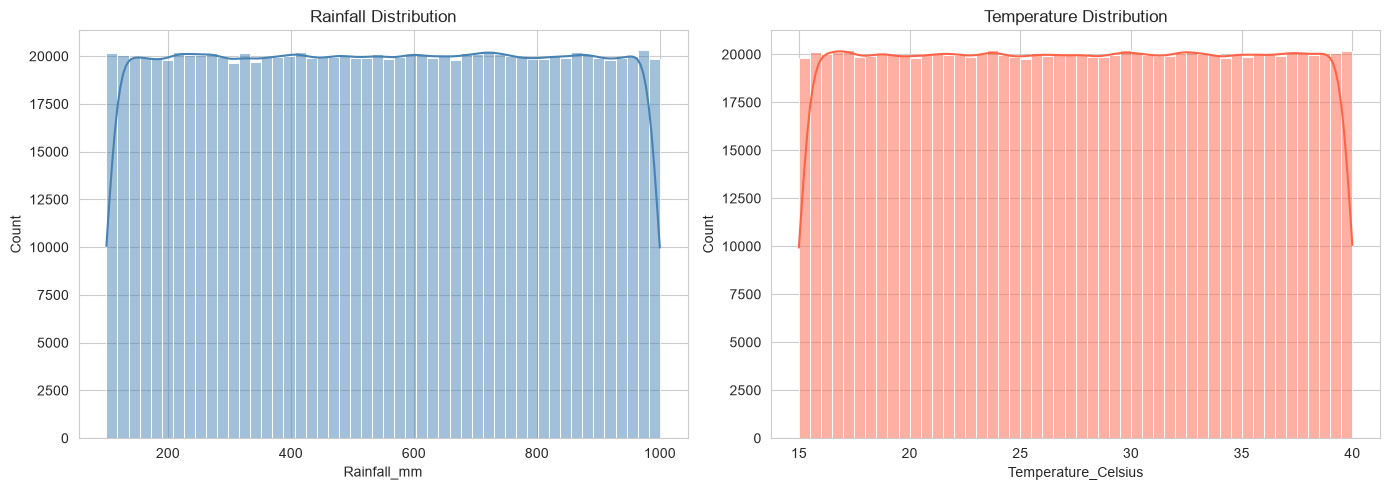

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Rainfall_mm"], kde=True, bins=50, color="steelblue", ax=axes[0])
axes[0].set_title("Rainfall Distribution")

sns.histplot(df["Temperature_Celsius"], kde=True, bins=50, color="tomato", ax=axes[1])
axes[1].set_title("Temperature Distribution")

plt.tight_layout()
plt.savefig("../reports/figures/02_rainfall_temperature_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26360\3643860568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Crop", ax=axes[0, 0], palette="viridis")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26360\3643860568.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Region", ax=axes[0, 1], palette="crest")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26360\3643860568.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Soil_Type", ax=axes[1, 0], palette="flare")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_

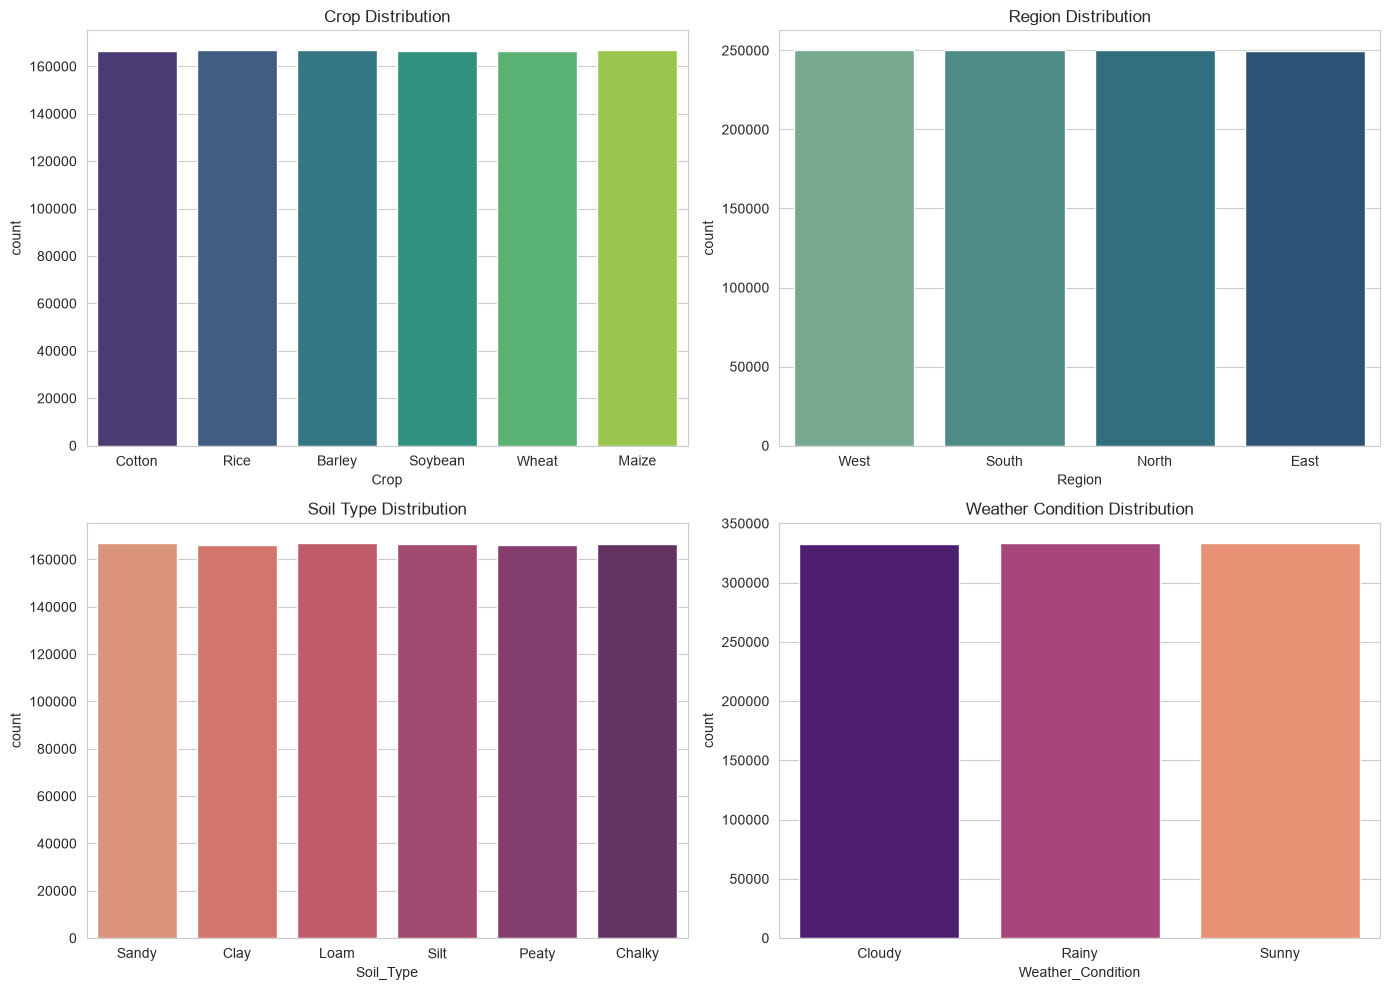

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="Crop", ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Crop Distribution")

sns.countplot(data=df, x="Region", ax=axes[0, 1], palette="crest")
axes[0, 1].set_title("Region Distribution")

sns.countplot(data=df, x="Soil_Type", ax=axes[1, 0], palette="flare")
axes[1, 0].set_title("Soil Type Distribution")

sns.countplot(data=df, x="Weather_Condition", ax=axes[1, 1], palette="magma")
axes[1, 1].set_title("Weather Condition Distribution")

plt.tight_layout()
plt.savefig("../reports/figures/03_categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26360\2812852307.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Crop", y="Yield_tons_per_hectare", palette="Set2")


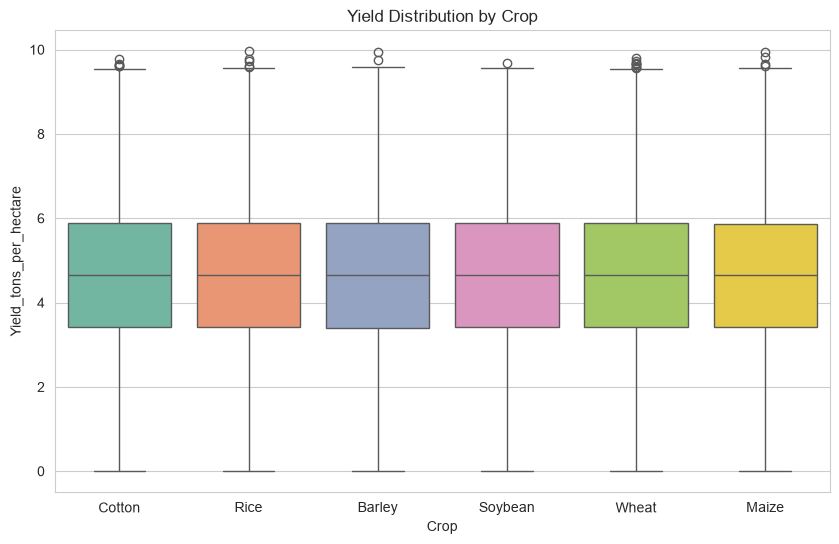

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Crop", y="Yield_tons_per_hectare", palette="Set2")
plt.title("Yield Distribution by Crop")
plt.savefig("../reports/figures/04_yield_by_crop.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26360\2658128233.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="Yield_tons_per_hectare", ax=axes[0], palette="Pastel1")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26360\2658128233.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Soil_Type", y="Yield_tons_per_hectare", ax=axes[1], palette="Set3")


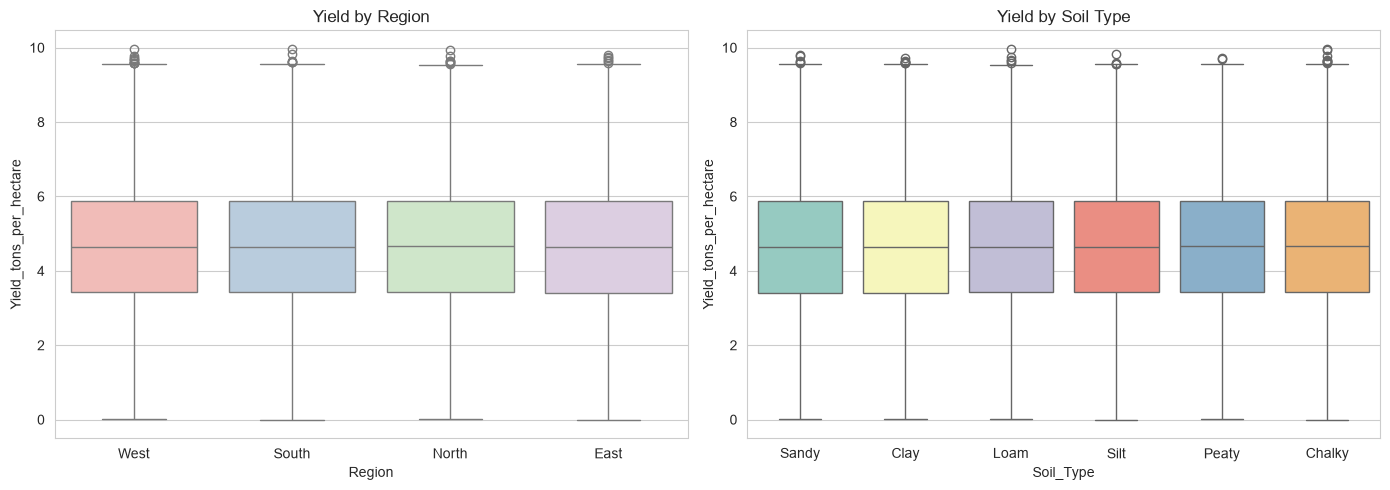

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Region", y="Yield_tons_per_hectare", ax=axes[0], palette="Pastel1")
axes[0].set_title("Yield by Region")

sns.boxplot(data=df, x="Soil_Type", y="Yield_tons_per_hectare", ax=axes[1], palette="Set3")
axes[1].set_title("Yield by Soil Type")

plt.tight_layout()
plt.savefig("../reports/figures/05_yield_by_region_soil.png", dpi=150, bbox_inches="tight")
plt.show()

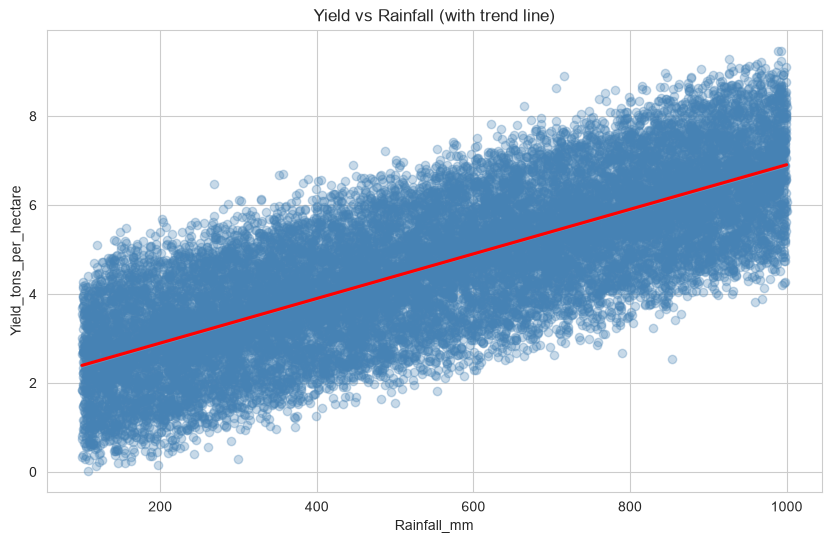

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(20000, random_state=42), x="Rainfall_mm", y="Yield_tons_per_hectare",
            scatter_kws={"alpha": 0.3, "color": "steelblue"}, line_kws={"color": "red"})
plt.title("Yield vs Rainfall (with trend line)")
plt.savefig("../reports/figures/06_yield_vs_rainfall.png", dpi=150, bbox_inches="tight")
plt.show()

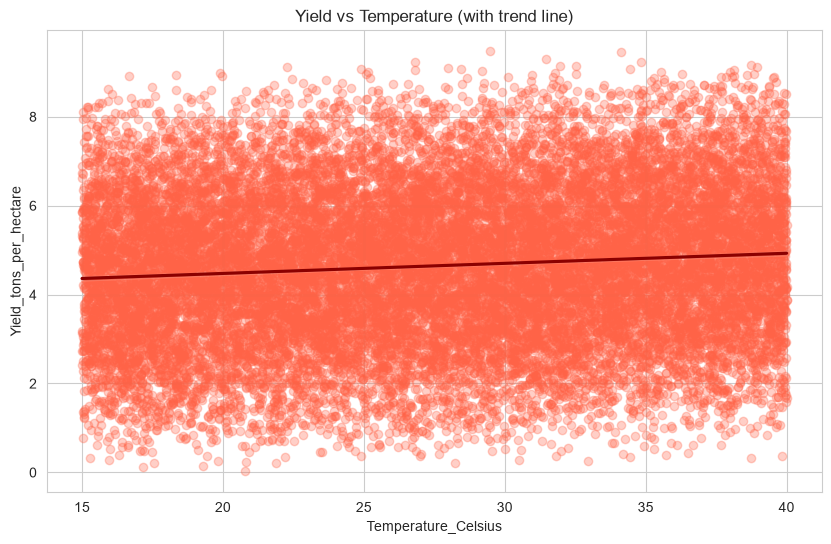

In [9]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(20000, random_state=42), x="Temperature_Celsius", y="Yield_tons_per_hectare",
            scatter_kws={"alpha": 0.3, "color": "tomato"}, line_kws={"color": "darkred"})
plt.title("Yield vs Temperature (with trend line)")
plt.savefig("../reports/figures/07_yield_vs_temperature.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26360\3813659117.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fertilizer_Used", y="Yield_tons_per_hectare", ax=axes[0], palette="Blues")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26360\3813659117.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Irrigation_Used", y="Yield_tons_per_hectare", ax=axes[1], palette="Greens")


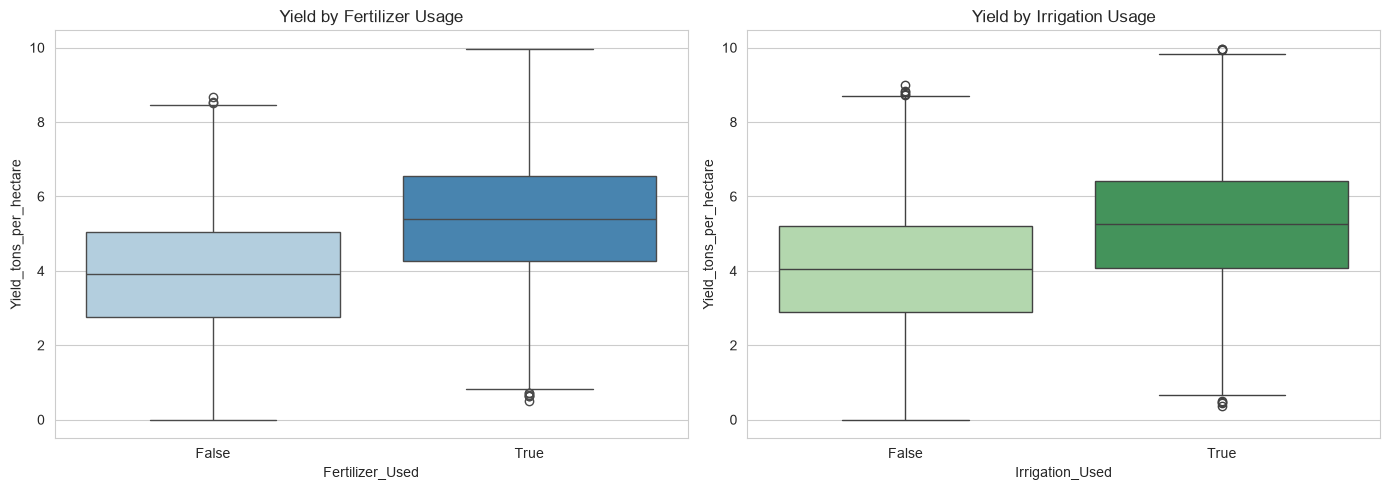

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Fertilizer_Used", y="Yield_tons_per_hectare", ax=axes[0], palette="Blues")
axes[0].set_title("Yield by Fertilizer Usage")

sns.boxplot(data=df, x="Irrigation_Used", y="Yield_tons_per_hectare", ax=axes[1], palette="Greens")
axes[1].set_title("Yield by Irrigation Usage")

plt.tight_layout()
plt.savefig("../reports/figures/08_yield_by_fertilizer_irrigation.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26360\990802333.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combo, x="Combo", y="Yield_tons_per_hectare", palette="rocket")


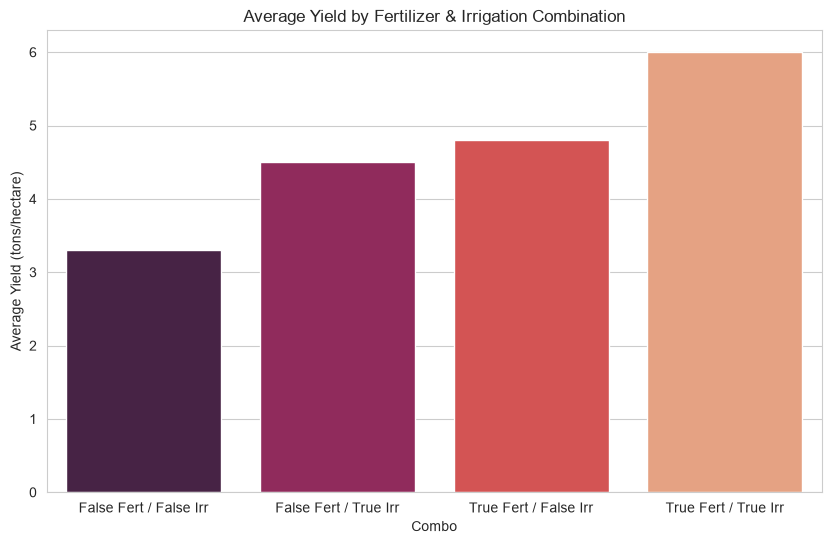

,Fertilizer_Used,Irrigation_Used,Yield_tons_per_hectare,Combo
0,False,False,3.305905,False Fert / False Irr
1,False,True,4.499366,False Fert / True Irr
2,True,False,4.799632,True Fert / False Irr
3,True,True,5.999009,True Fert / True Irr


In [11]:
combo = df.groupby(["Fertilizer_Used", "Irrigation_Used"])["Yield_tons_per_hectare"].mean().reset_index()
combo["Combo"] = combo["Fertilizer_Used"].astype(str) + " Fert / " + combo["Irrigation_Used"].astype(str) + " Irr"

plt.figure(figsize=(10, 6))
sns.barplot(data=combo, x="Combo", y="Yield_tons_per_hectare", palette="rocket")
plt.title("Average Yield by Fertilizer & Irrigation Combination")
plt.ylabel("Average Yield (tons/hectare)")
plt.savefig("../reports/figures/09_fertilizer_irrigation_interaction.png", dpi=150, bbox_inches="tight")
plt.show()

combo

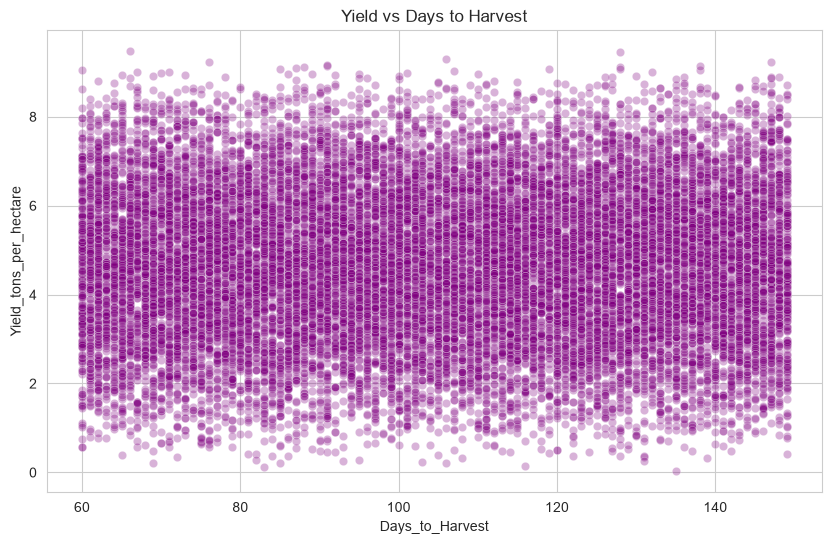

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(20000, random_state=42), x="Days_to_Harvest", y="Yield_tons_per_hectare",
                alpha=0.3, color="purple")
plt.title("Yield vs Days to Harvest")
plt.savefig("../reports/figures/10_yield_vs_days_to_harvest.png", dpi=150, bbox_inches="tight")
plt.show()

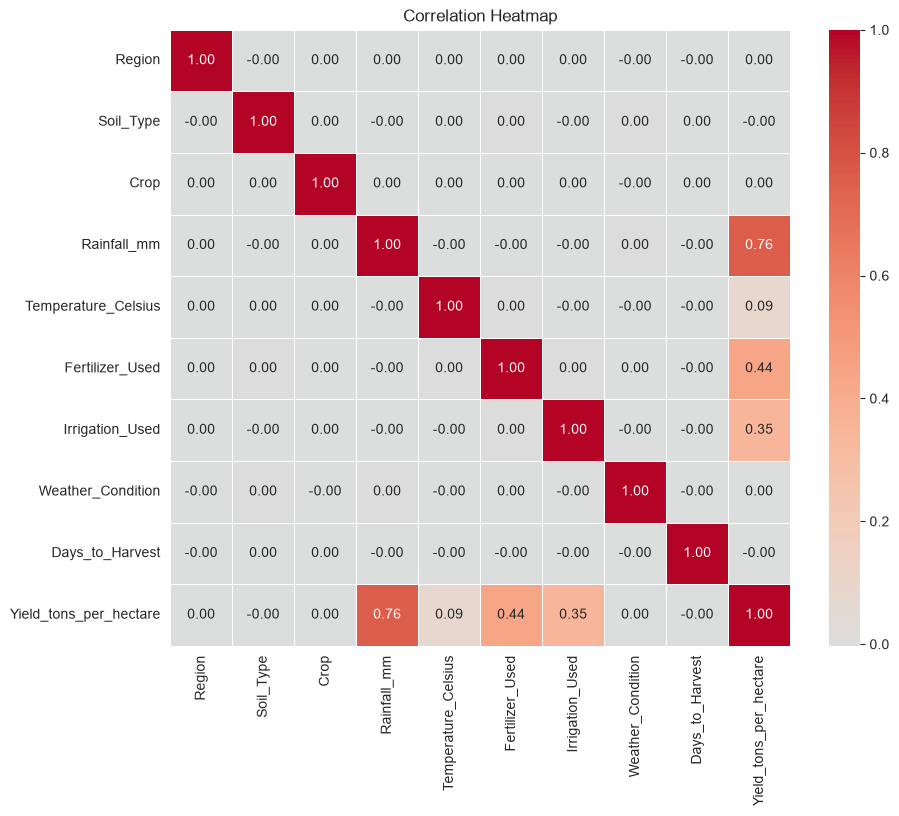

In [13]:
corr_df = df.copy()
for col in ["Region", "Soil_Type", "Crop", "Weather_Condition"]:
    corr_df[col] = corr_df[col].astype("category").cat.codes
corr_df["Fertilizer_Used"] = corr_df["Fertilizer_Used"].astype(int)
corr_df["Irrigation_Used"] = corr_df["Irrigation_Used"].astype(int)

plt.figure(figsize=(10, 8))
corr = corr_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.savefig("../reports/figures/11_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
import json

eda_summary = {
    "strongest_positive_driver": "Rainfall_mm",
    "moderate_drivers": ["Fertilizer_Used", "Irrigation_Used"],
    "weak_drivers": ["Temperature_Celsius", "Days_to_Harvest"],
    "no_signal_categoricals": ["Region", "Soil_Type", "Crop", "Weather_Condition"],
    "figures_generated": 11,
    "notes": (
        "EDA confirms rainfall is the dominant driver of yield, with fertilizer and "
        "irrigation usage providing substantial secondary boosts, especially in "
        "combination. Temperature and days to harvest show weak influence. "
        "Categorical location/soil/crop/weather variables show minimal standalone "
        "correlation but may still contribute via interaction effects."
    )
}

with open("../reports/eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=4)

eda_summary

{'strongest_positive_driver': 'Rainfall_mm',
 'moderate_drivers': ['Fertilizer_Used', 'Irrigation_Used'],
 'weak_drivers': ['Temperature_Celsius', 'Days_to_Harvest'],
 'no_signal_categoricals': ['Region',
  'Soil_Type',
  'Crop',
  'Weather_Condition'],
 'figures_generated': 11,
 'notes': 'EDA confirms rainfall is the dominant driver of yield, with fertilizer and irrigation usage providing substantial secondary boosts, especially in combination. Temperature and days to harvest show weak influence. Categorical location/soil/crop/weather variables show minimal standalone correlation but may still contribute via interaction effects.'}